### Notebook Data Mining – Processus KDD sur un Dataset Marketing
##### Thème du projet

Analyse d’un dataset marketing afin de comprendre le comportement des clients et prédire les clients susceptibles d’acheter un produit.

### Rappel des étapes :
Le processus KDD permet d’extraire des connaissances utiles à partir des données.
Les étapes sont :

1. Compréhension du domaine
2. Sélection des données
3. Nettoyage des données
4. Transformation des données
5. Data Mining
6. Évaluation
7. Présentation des connaissances

#### Description du dataset
Nom : Marketing Campaign Dataset
Ce dataset contient des informations sur des clients d’une entreprise de marketing :

- âge
- revenu
- niveau d’étude
- situation matrimoniale
- dépenses
- nombre d’achats
- réponse aux campagnes marketing

Ce dataset est très adapté pour appliquer les étapes du processus KDD (Knowledge Discovery in Databases).

In [8]:
# Importation des packages
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

import warnings
warnings.filterwarnings('ignore')

In [13]:
# Lecture du fichier
df=pd.read_csv('marketing_campaign.csv', sep="\t")
df

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,...,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,...,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,...,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,...,3,0,0,0,0,0,0,3,11,0


In [14]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,5,0,0,0,0,0,0,3,11,0


### Étape 1 : Compréhension du domaine
Objectif : 

Comprendre le problème métier.

Dans ce projet, l’entreprise souhaite identifier les clients qui répondent positivement aux campagnes marketing.

In [15]:
df.tail()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
2235,10870,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,...,5,0,0,0,0,0,0,3,11,0
2236,4001,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,...,7,0,0,0,1,0,0,3,11,0
2237,7270,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,...,6,0,1,0,0,0,0,3,11,0
2238,8235,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,...,3,0,0,0,0,0,0,3,11,0
2239,9405,1954,PhD,Married,52869.0,1,1,15-10-2012,40,84,...,7,0,0,0,0,0,0,3,11,1


In [16]:
df.shape

(2240, 29)

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [18]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [19]:
df.describe(include = "O")

,Education,Marital_Status,Dt_Customer
count,2240,2240,2240
unique,5,8,663
top,Graduation,Married,31-08-2012
freq,1127,864,12


In [20]:
df.duplicated().sum()  

np.int64(0)

### Fill missing

In [12]:
df['Income'].fillna(df['Income'].mean(), inplace=True)

### Étape 2 : Sélection des données
Objectif

Choisir les variables importantes.

In [13]:
df.drop(columns=['ID'], inplace=True)
df

,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,...,7,0,0,0,0,0,0,3,11,1
1,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,...,5,0,0,0,0,0,0,3,11,0
2,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,...,4,0,0,0,0,0,0,3,11,0
3,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,...,6,0,0,0,0,0,0,3,11,0
4,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,...,5,0,0,0,0,0,0,3,11,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,1967,Graduation,Married,61223.0,0,1,13-06-2013,46,709,43,...,5,0,0,0,0,0,0,3,11,0
2236,1946,PhD,Together,64014.0,2,1,10-06-2014,56,406,0,...,7,0,0,0,1,0,0,3,11,0
2237,1981,Graduation,Divorced,56981.0,0,0,25-01-2014,91,908,48,...,6,0,1,0,0,0,0,3,11,0
2238,1956,Master,Together,69245.0,0,1,24-01-2014,8,428,30,...,3,0,0,0,0,0,0,3,11,0


In [23]:
colonnes = [
    'Year_Birth',
    'Education',
    'Marital_Status',
    'Income',
    'MntWines',
    'MntFruits',
    'NumWebPurchases',
    'NumStorePurchases',
    'Response'
]

selected_df = df[colonnes]

selected_df.head()

,Year_Birth,Education,Marital_Status,Income,MntWines,MntFruits,NumWebPurchases,NumStorePurchases,Response
0,1957,Graduation,Single,58138.0,635,88,8,4,1
1,1954,Graduation,Single,46344.0,11,1,1,2,0
2,1965,Graduation,Together,71613.0,426,49,8,10,0
3,1984,Graduation,Together,26646.0,11,4,2,4,0
4,1981,PhD,Married,58293.0,173,43,5,6,0


### Étape 3 : Nettoyage des données
Objectif

Corriger les valeurs manquantes et les incohérences.

In [21]:
df.isnull().sum()  

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [25]:
selected_df = selected_df.dropna()

print(selected_df.isnull().sum())# Vérification des valeurs manquantes
print(selected_df)

Year_Birth           0
Education            0
Marital_Status       0
Income               0
MntWines             0
MntFruits            0
NumWebPurchases      0
NumStorePurchases    0
Response             0
dtype: int64
      Year_Birth   Education Marital_Status   Income  MntWines  MntFruits  \
0           1957  Graduation         Single  58138.0       635         88   
1           1954  Graduation         Single  46344.0        11          1   
2           1965  Graduation       Together  71613.0       426         49   
3           1984  Graduation       Together  26646.0        11          4   
4           1981         PhD        Married  58293.0       173         43   
...          ...         ...            ...      ...       ...        ...   
2235        1967  Graduation        Married  61223.0       709         43   
2236        1946         PhD       Together  64014.0       406          0   
2237        1981  Graduation       Divorced  56981.0       908         48   
2238      

### Étape 4 : Transformation des données
Objectif : 

Préparer les données pour les algorithmes.

In [26]:
# Encodage des variables catégorielles
le = LabelEncoder()

selected_df['Education'] = le.fit_transform(selected_df['Education'])
selected_df['Marital_Status'] = le.fit_transform(selected_df['Marital_Status'])

print(selected_df.head())

   Year_Birth  Education  Marital_Status   Income  MntWines  MntFruits  \
0        1957          2               4  58138.0       635         88   
1        1954          2               4  46344.0        11          1   
2        1965          2               5  71613.0       426         49   
3        1984          2               5  26646.0        11          4   
4        1981          4               3  58293.0       173         43   

   NumWebPurchases  NumStorePurchases  Response  
0                8                  4         1  
1                1                  2         0  
2                8                 10         0  
3                2                  4         0  
4                5                  6         0  


### Visualisation des données

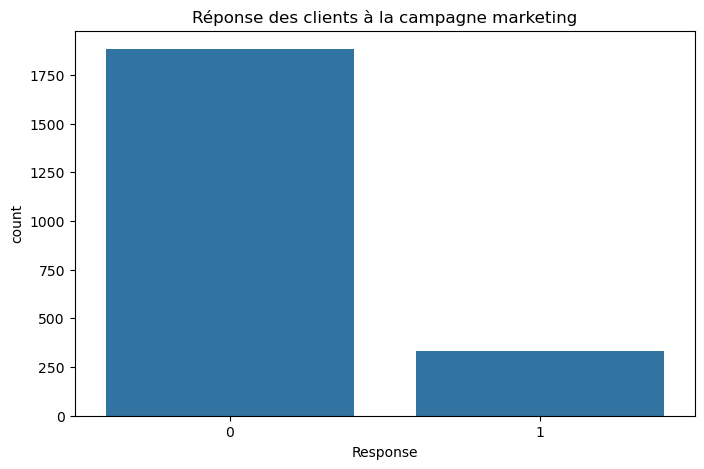

In [27]:
plt.figure(figsize=(8,5))
sns.countplot(x='Response', data=selected_df)
plt.title('Réponse des clients à la campagne marketing')
plt.show()

<Axes: xlabel='Marital_Status'>

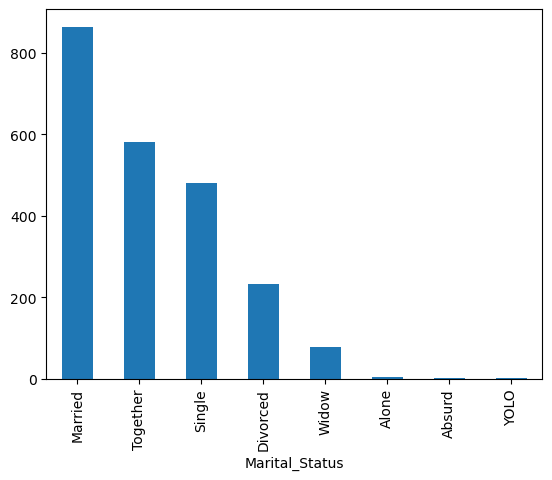

In [28]:
df["Marital_Status"].value_counts().plot(kind="bar")

<Axes: ylabel='count'>

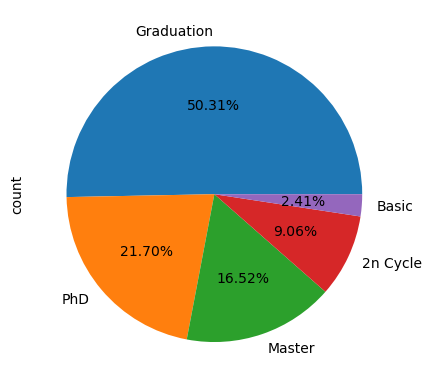

In [29]:
df['Education'].value_counts().plot(kind="pie", autopct="%0.02f%%")

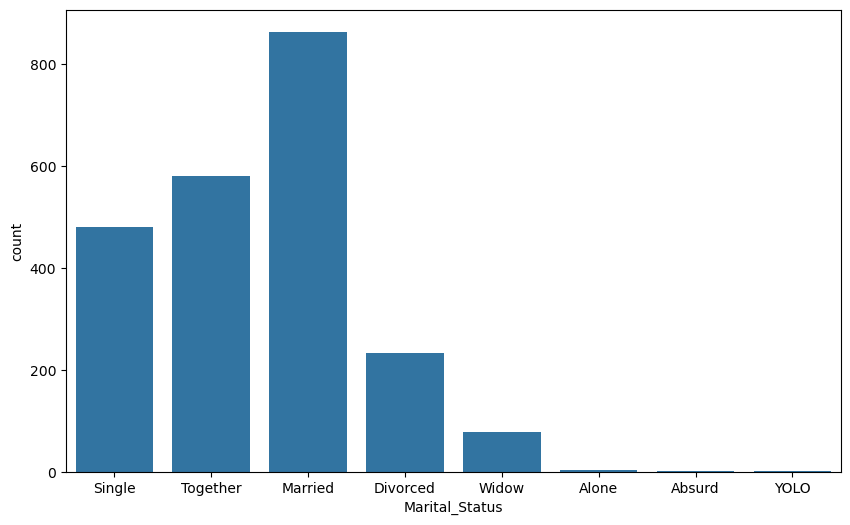

In [30]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Marital_Status')
plt.show()

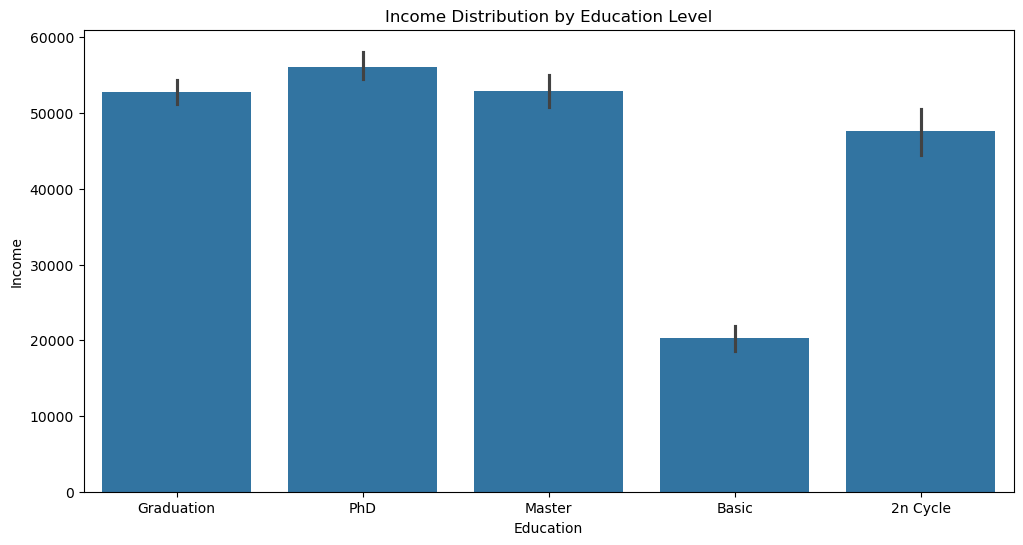

In [31]:
plt.figure(figsize=(12,6))
sns.barplot(x='Education', y='Income', data=df)
plt.title('Income Distribution by Education Level')
plt.show()

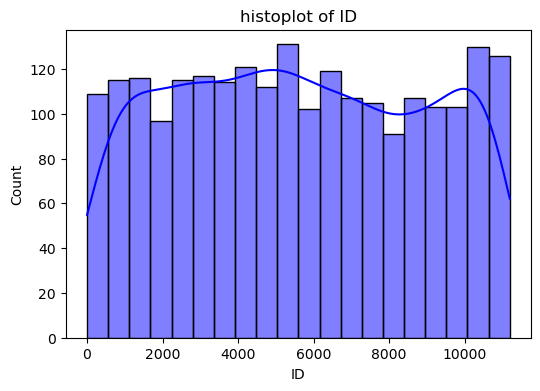

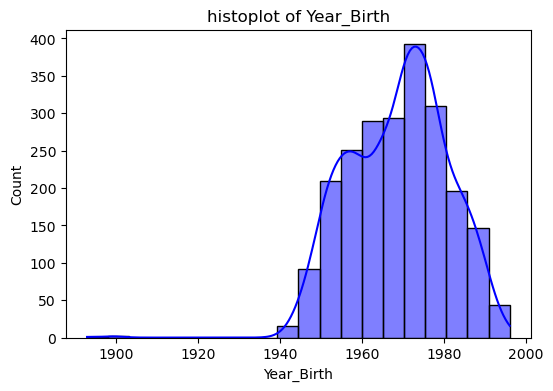

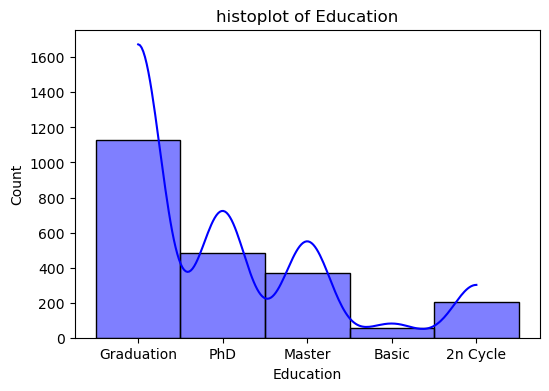

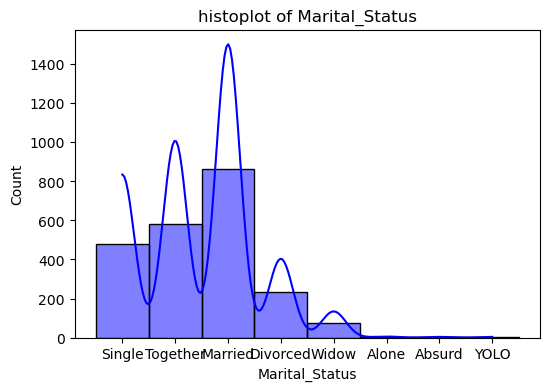

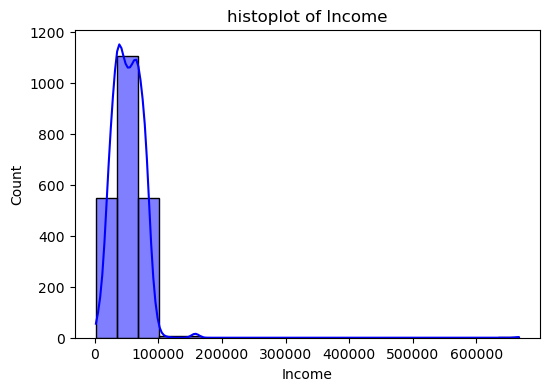

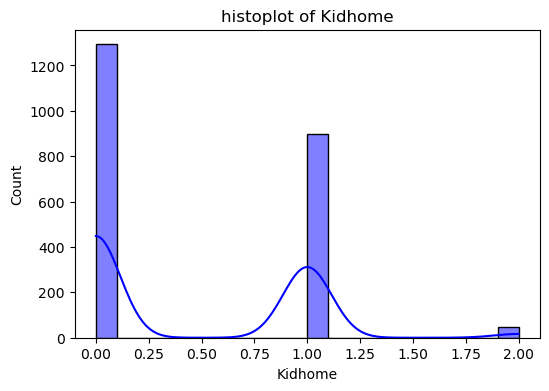

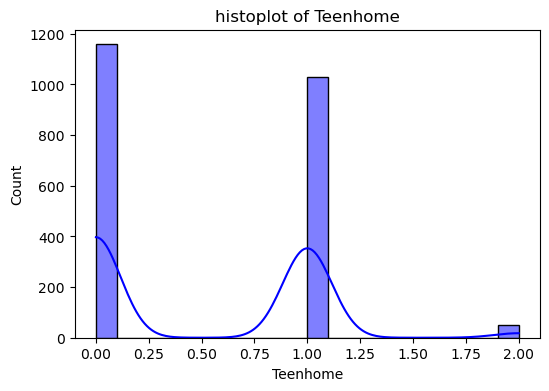

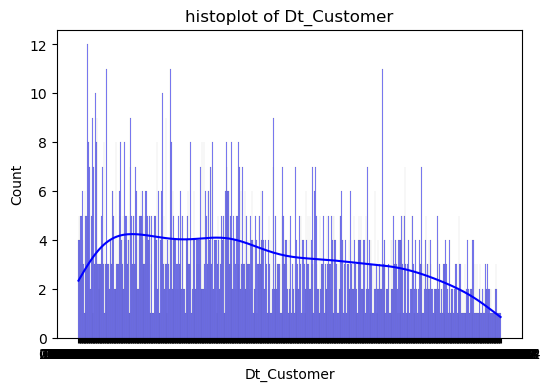

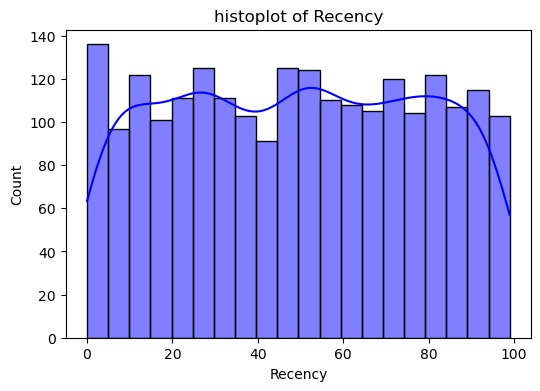

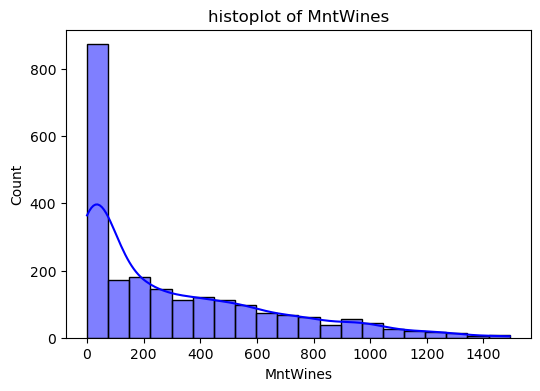

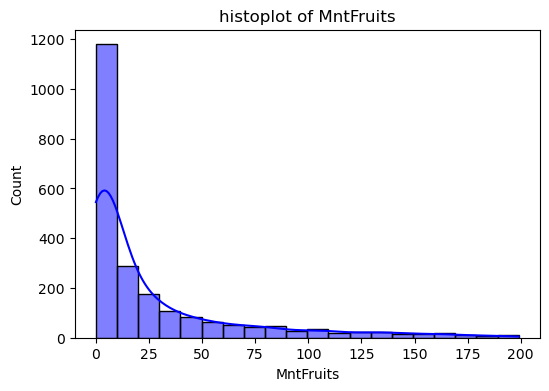

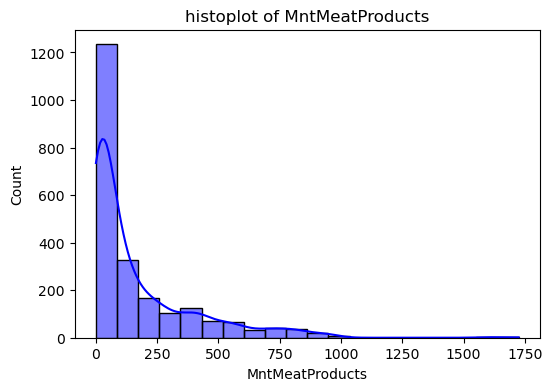

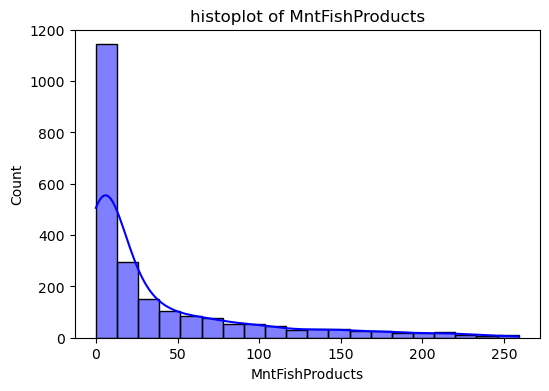

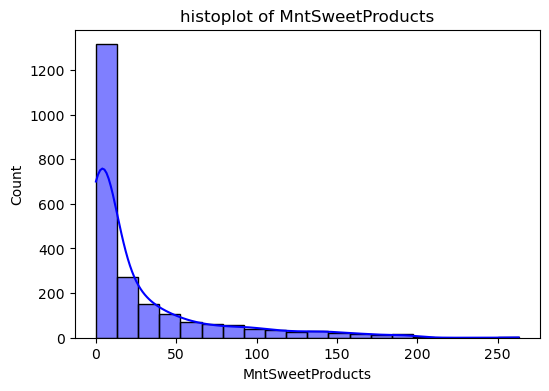

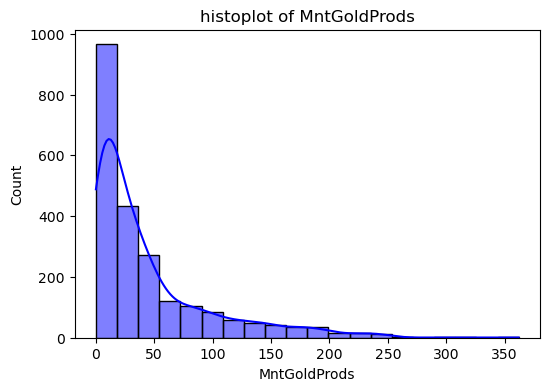

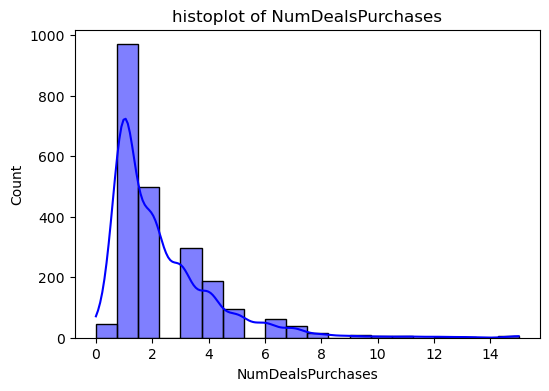

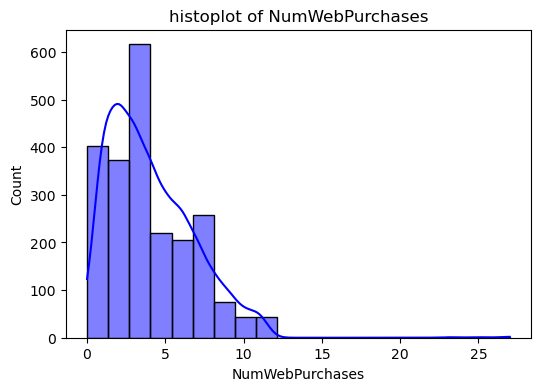

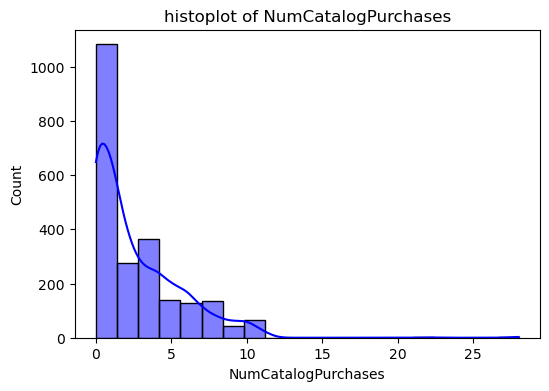

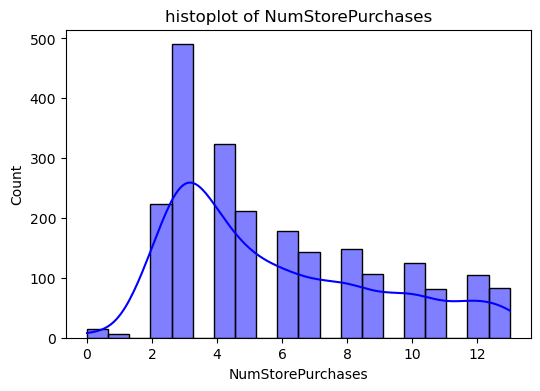

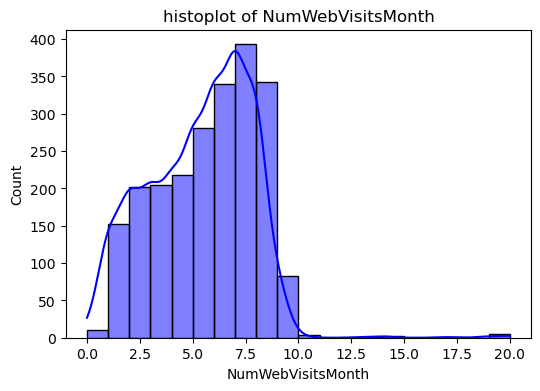

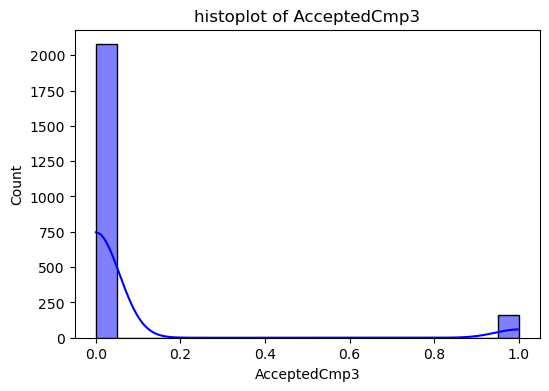

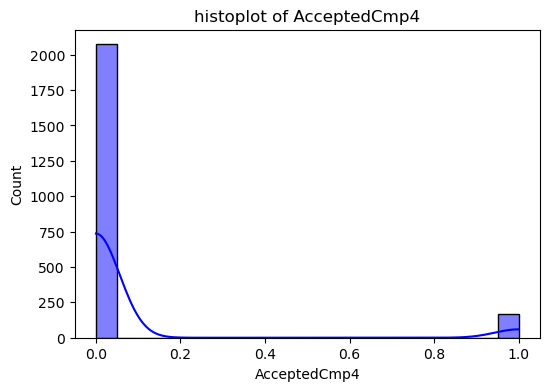

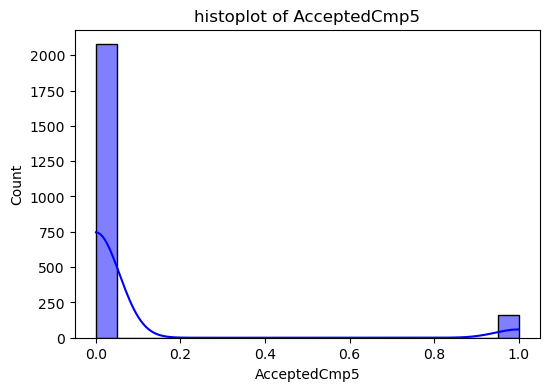

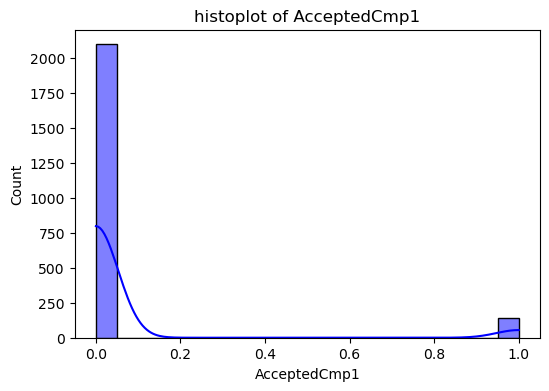

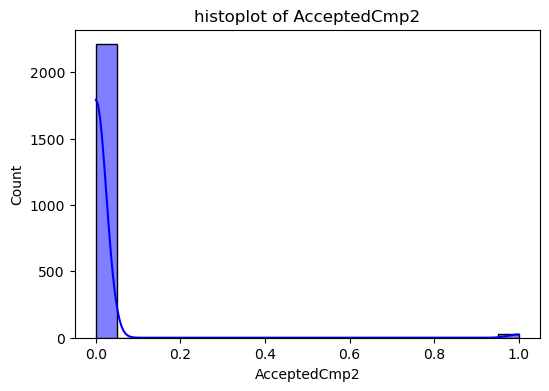

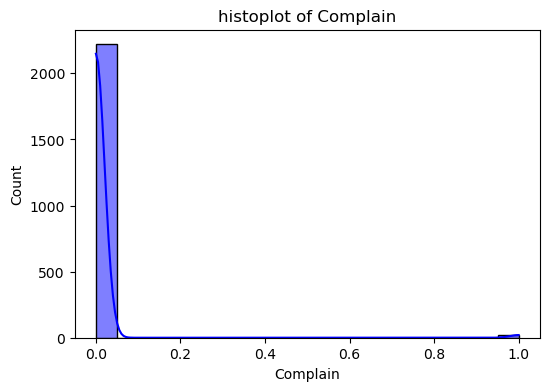

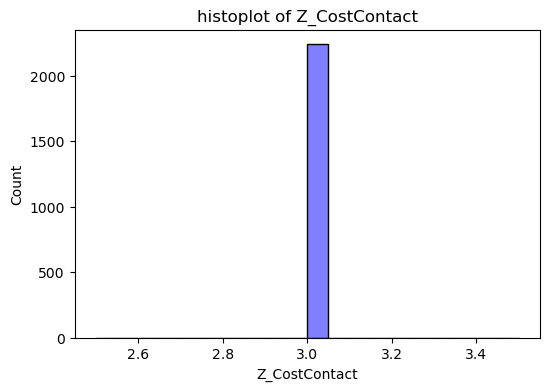

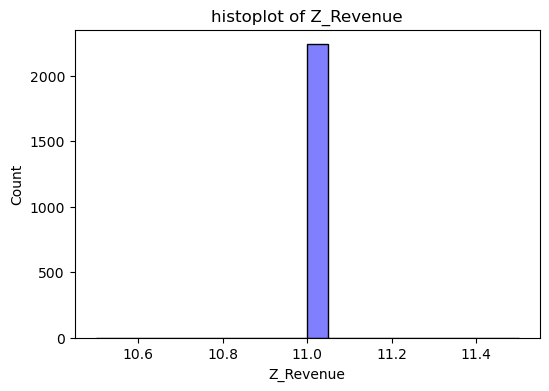

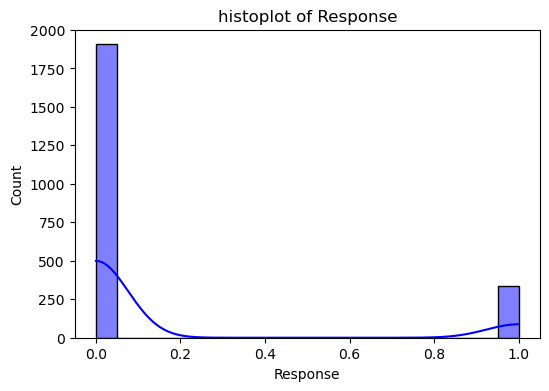

In [32]:
for col in df.columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col] , kde = True, bins = 20 , color = 'blue')
    plt.xlabel(col)
    plt.title(f'histoplot of {col}')
    plt.show()

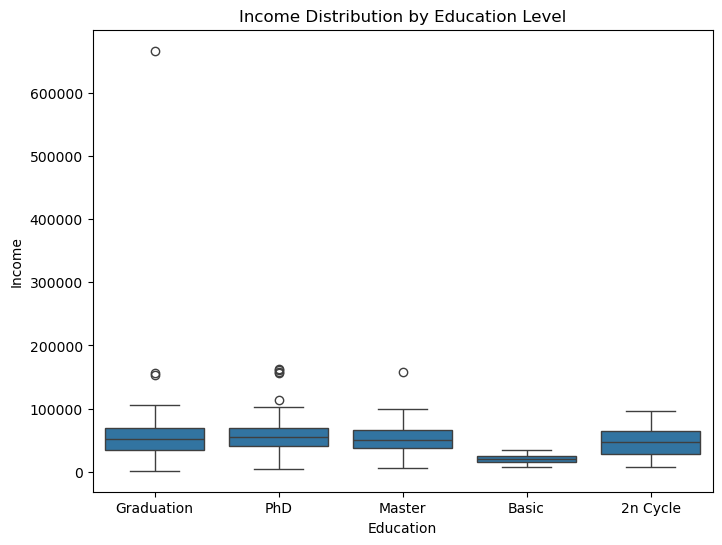

In [33]:
plt.figure(figsize=(8,6))
sns.boxplot(x='Education', y='Income', data=df)
plt.title('Income Distribution by Education Level')
plt.show()

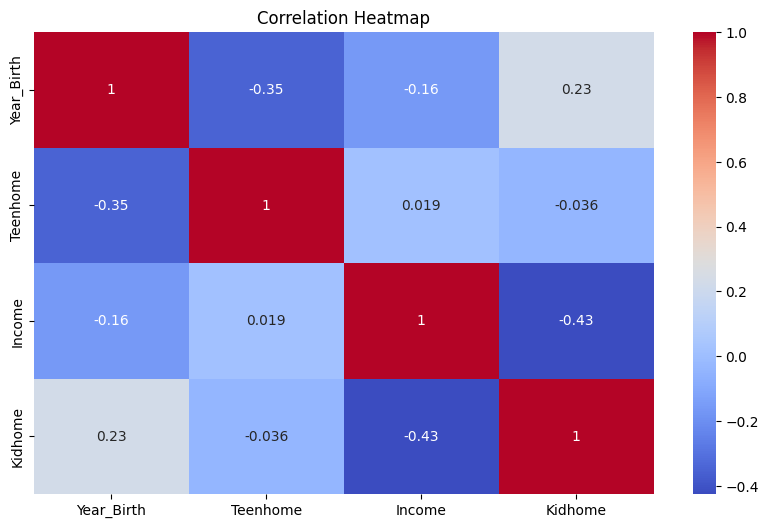

In [25]:
cols = ['Year_Birth','Teenhome','Income','Kidhome']  

plt.figure(figsize=(10,6))
sns.heatmap(df[cols].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


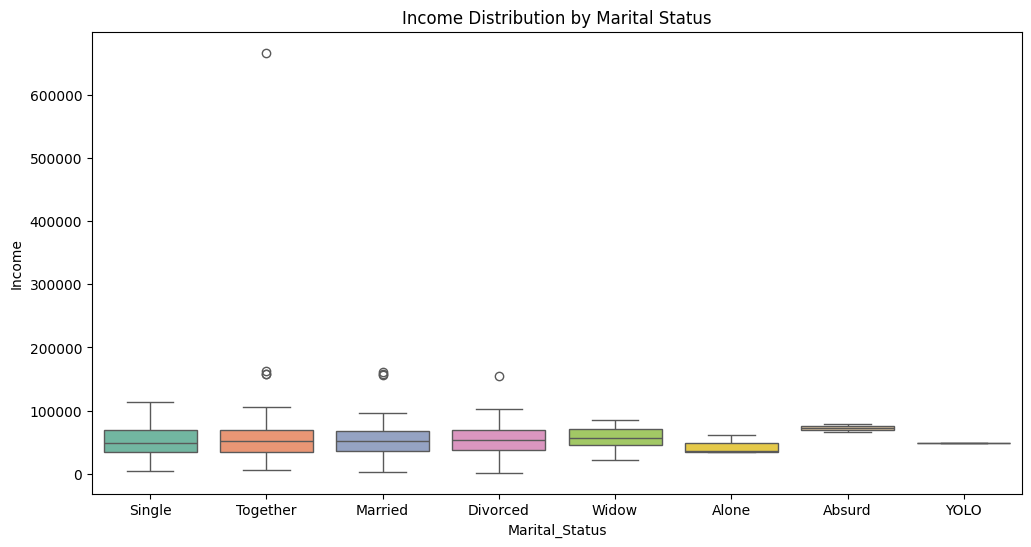

In [26]:
plt.figure(figsize=(12,6))
sns.boxplot(x='Marital_Status', y='Income', data=df, palette='Set2')
plt.title('Income Distribution by Marital Status')
plt.show()


### Étape 5 : Data Mining
Objectif

Appliquer un algorithme de Machine Learning.

Ici nous utilisons Random Forest pour prédire les réponses des clients.

In [34]:
# Variables explicatives
X = selected_df.drop('Response', axis=1)

# Variable cible
y = selected_df['Response']

# Séparation des données
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# Création du modèle
model = RandomForestClassifier()

# Entraînement
model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


### Étape 6 : Évaluation
Objectif

Mesurer les performances du modèle.

In [35]:
# Prédictions
predictions = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, predictions)

print("Accuracy :", accuracy)

# Rapport détaillé
print(classification_report(y_test, predictions))

Accuracy : 0.8738738738738738
              precision    recall  f1-score   support

           0       0.89      0.98      0.93       382
           1       0.62      0.24      0.35        62

    accuracy                           0.87       444
   macro avg       0.76      0.61      0.64       444
weighted avg       0.85      0.87      0.85       444



### Étape 7 : Présentation des connaissances
Résultats obtenus

Grâce au modèle de Machine Learning, nous pouvons :

identifier les clients susceptibles d’accepter une campagne marketing ;
mieux cibler les publicités ;
réduire les coûts marketing ;
améliorer les ventes de l’entreprise.

##### Tester le modele

In [36]:
# Sélection d'un échantillon aléatoire
echantillon = selected_df.sample(10, random_state=42)
print(echantillon)

      Year_Birth  Education  Marital_Status   Income  MntWines  MntFruits  \
961         1962          4               4  52597.0       492          0   
229         1986          4               5  34320.0         4          1   
1093        1972          4               4  38578.0        38          4   
427         1989          2               3  75433.0       800          0   
1650        1982          2               3  22448.0         3          1   
543         1982          4               3  84169.0      1478         19   
1801        1974          2               5  75702.0      1073          0   
1708        1978          2               3  64813.0       293          0   
994         1954          2               2  64587.0        66          0   
976         1959          3               5  82576.0      1206         55   

      NumWebPurchases  NumStorePurchases  Response  
961                 6                  8         0  
229                 1                  2      

In [37]:
X_sample = echantillon.drop('Response', axis=1)
y_sample = echantillon['Response']

In [39]:
# Prédiction sur l'échantillon
pred_sample = model.predict(X_sample)
# Comparaison réel vs prédiction
resultats = echantillon.copy()
resultats['Prediction'] = pred_sample
print(resultats[['Response', 'Prediction']])

      Response  Prediction
961          0           0
229          0           0
1093         0           0
427          0           0
1650         0           0
543          1           1
1801         0           0
1708         0           0
994          0           0
976          0           0
